In [18]:
%reload_ext autoreload
%autoreload 2
%cd ~/erc-src/cuneiform-ocr-sign-alignment-worktree # Change to the project directory
%env PATH=$HOME/.local/bin:$PATH
    
import json
import os
import requests
import numpy as np
import cv2
from PIL import Image
from pymongo import MongoClient
# from mmdet.apis import init_detector, inference_detector
# from mmdet.utils import register_all_modules
from data_processing.divide_photos import divide_tablet_photo
from sign_alignment.detector import ModelConfig, TabletImageDetector

# import signs_alignment as sa
import os
import torch
from dotenv import load_dotenv

ANNOTATIONS_DIR = os.path.expanduser("~/erc-work-data/data-of-cuneiform-ocr-data/filtered_annotations")
CONFIG_FILE = "configs/detr.py"
CHECKPOINT_FILE = os.path.expanduser("~/erc-work-data/retrained_models/detr-173/epoch_1000.pth")
# # temporal change
# CHECKPOINT_FILE = os.path.expanduser("~/epoch_1000.pth")
# # ---
SCORE_THRESHOLD = 0.5
Y_THRESHOLD = 35  # for grouping signs into lines
OUTPUT_DIR = "alignment_results"
SAMPLE_LIMIT = 5  # number of samples to process

load_dotenv()
MONGODB_URI = os.getenv('MONGODB_URI', 'YOUR_MONGODB_URI')

# colors for visualization
GT_COLOR = (0, 255, 0)  # Green for GT
DET_COLOR = (255, 0, 0)  # Red for Detected
OPTIM_COLOR = (0, 255, 255)  # cyan for Optimized

[Errno 2] No such file or directory: '/home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree # Change to the project directory'
/home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree
env: PATH=$HOME/.local/bin:$PATH


In [19]:
model_config = ModelConfig(
    config_file=CONFIG_FILE,
    checkpoint_file=CHECKPOINT_FILE,
    device='auto'
)
tablet_detector = TabletImageDetector(
    model_config=model_config,
    score_threshold=SCORE_THRESHOLD,
    keep_crops=True
)

Initializing detector, loading model...
Using device: cuda:0
Loads checkpoint by local backend from path: /home/jebediahc/erc-work-data/retrained_models/detr-173/epoch_1000.pth


In [20]:
from sign_alignment.data_source import LocalDataSource

local_source = LocalDataSource(ANNOTATIONS_DIR)
fragments = local_source.get_available_fragments()
print(f"Found {len(fragments)} fragments with both image and annotation")
sample = fragments[0] # NBC.4020
sample = fragments[9] # HS.2086
print(f"Processing sample: {sample}")


Found 947 fragments with both image and annotation
Processing sample: HS.2086


In [ ]:
# show groud truth boxes
from sign_alignment.visualizer import BboxVisualizer

img = local_source.load_image(sample)
gt_boxes = local_source.load_annotation(sample)
print(f"Ground truth boxes: {gt_boxes}")

gt_bbox_visualizer = BboxVisualizer(color=(0, 255, 0)) # green for gt
gt_bbox_visualizer.draw_boxes(img.copy(), gt_boxes)
# gt_bbox_visualizer.display_result(vis_opt = "save", path = )
gt_bbox_visualizer.show_draw()
gt_bbox_visualizer.save(os.path.join(OUTPUT_DIR, f"debug_{sample}_gt.jpg"))


In [22]:
# get sign text (gt)
from sign_alignment.data_source import EBLAPISource, SignTextParser
from sign_alignment.visualizer import TextVisualizer

api_source = EBLAPISource()
signs_text = api_source.get_signs(sample)
if signs_text is None:
    raise ValueError(f"No sign text found for sample {sample}")
print(f"  Raw API signs (first 50 chars): {signs_text[:50]}...")

text_lines = SignTextParser.parse_api_signs(signs_text)
total_text_signs = sum(len(line) for line in text_lines)
print(f"  Text lines: {len(text_lines)}, total signs: {total_text_signs}")
# print all text lines
TextVisualizer.save_text(text_lines, path=os.path.join(OUTPUT_DIR, f"debug_{sample}_text.txt"), fragment_id=sample)

  Raw API signs (first 50 chars): ABZ480 ABZ535 ABZ319 ABZ207 ABZ449 ABZ537 ABZ144 A...
  Text lines: 47, total signs: 565


In [ ]:
# detect signs
from sign_alignment.visualizer import BboxVisualizer

# Use tablet_detector created in cell 2
detections = tablet_detector.detect(img)

det_bbox_visualizer = BboxVisualizer(color=DET_COLOR)
det_bbox_visualizer.draw_boxes(img.copy(), detections)
det_bbox_visualizer.display_result(vis_opt = "save", path = os.path.join(OUTPUT_DIR, f"debug_{sample}_det.jpg"))

cropped = tablet_detector.get_cropped_images()
exp_image_idx = 1
exp_image = cropped[exp_image_idx]


det_bbox_visualizer.draw_boxes(exp_image.img.copy(), exp_image.detections)
det_bbox_visualizer.display_result(vis_opt = "draw", path = os.path.join(OUTPUT_DIR, f"debug_{sample}_exp_image.jpg"))

In [24]:
# Transform GT boxes for exp_image (cropped region)
from sign_alignment import transform_gt_to_cropped_region

# exp_image is cropped[3], so we need crop_coordinates[3]
crop_info = tablet_detector.crop_coordinates[exp_image_idx]

print(f"Crop info for exp_image (index {exp_image_idx}): x={crop_info['x']}, y={crop_info['y']}, w={crop_info['w']}, h={crop_info['h']}")

# Transform GT boxes to exp_image coordinates
gt_boxes_exp = transform_gt_to_cropped_region(gt_boxes, crop_info)
print(f"GT boxes in full image: {len(gt_boxes)}")
print(f"GT boxes in exp_image: {len(gt_boxes_exp)}")

# Visualize GT boxes on exp_image
if gt_boxes_exp:
    gt_exp_bbox_visualizer = BboxVisualizer(color=GT_COLOR)  
    gt_exp_bbox_visualizer.draw_boxes(exp_image.img.copy(), gt_boxes_exp)
    gt_exp_bbox_visualizer.display_result(vis_opt="save", path=os.path.join(OUTPUT_DIR, f"debug_{sample}_exp_gt.jpg"))

Crop info for exp_image (index 1): x=908, y=95, w=1262, h=2835
GT boxes in full image: 397
GT boxes in exp_image: 187
✓ Saved to: /home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree/alignment_results/debug_HS.2086_exp_gt.jpg


In [25]:
# statistics
from sign_alignment import compute_avg_dimensions

avg_width, avg_height = compute_avg_dimensions(detections)
print(f"full image shape: {img.shape}")
print(f"Exp image shape: {exp_image.img.shape}")
print(f"Average detected sign width: {avg_width:.2f}, height: {avg_height:.2f}")

full image shape: (8830, 3071, 3)
Exp image shape: (2835, 1262, 3)
Average detected sign width: 138.99, height: 133.66


In [26]:
# create sub-tablets, text and detection, for further alignment
from sign_alignment import SubTablet

# --- 1. Detection SubTablet (target X) ---
sub_tablet_detection = SubTablet.from_detections(
    img=exp_image.img,
    detections=exp_image.detections,
    name="detection",
    avg_width=avg_width,
    avg_height=avg_height,
)

# --- 2. Text SubTablet (source S), centroid-initialised ---
# the signs are distributed in lines using avg_width and avg_height, and aligned to the centroid of the detection boxes. But it doesn't matter if we don't use the boxes positions information.
sub_tablet_text = SubTablet.from_text_lines(
    text_lines=text_lines,
    avg_width=avg_width,
    avg_height=avg_height,
    img=exp_image.img,
    target_detections=exp_image.detections,
    align_to_detection_centroid=True,
    name="text",
) 

print(f"Sub-tablet detection: {sub_tablet_detection.info}")
print(f"Sub-tablet text: {sub_tablet_text.info}")

Sub-tablet detection: SubTablet 'detection': 100 signs, 1 rows, image shape: (2835, 1262, 3), heatmap shape: None
Sub-tablet text: SubTablet 'text': 565 signs, 47 rows, image shape: (2835, 1262, 3), heatmap shape: None


In [27]:
# 从这里开始添加我们的optimize前处理

# ===== Step 1: Row Detection using DBSCAN =====

# Detect rows in sub_tablet_detection and update row_idx for all sign_boxes
# Using custom distance metric: Dist(A,B) = sqrt(lambda*(x_A-x_B)^2 + (y_A-y_B)^2)
# where lambda=0.05 emphasizes y-coordinate proximity
# 
# Distance is normalized by average sign size for scale invariance:
# eps=0.6 means boxes within 0.6 * avg_size are considered neighbors
num_rows = sub_tablet_detection.detect_rows(
    eps=0.4,           # Distance threshold as multiple of avg sign size
    min_samples=1,     # Minimum samples per cluster
    lambda_weight=0.007 # Weight for x-coordinate (emphasizes y)
)

print(f"=== Row Detection Results (Scale-Normalized) ===")
print(f"Average sign size: {(sub_tablet_detection.avg_width + sub_tablet_detection.avg_height) / 2:.2f} pixels")
print(f"eps=0.6 → actual distance threshold ≈ {0.6 * (sub_tablet_detection.avg_width + sub_tablet_detection.avg_height) / 2:.2f} pixels")
print(f"Detected {num_rows} rows")
print(f"Number of signs: {len(sub_tablet_detection)}")

# Count boxes per row
from collections import Counter
row_labels = [sb.row_idx for sb in sub_tablet_detection.sign_boxes]
row_counts = Counter(row_labels)
print(f"\nBoxes per row:")
for row_idx in sorted(row_counts.keys()):
    if row_idx == -1:
        print(f"  Noise: {row_counts[row_idx]} boxes")
    else:
        print(f"  Row {row_idx}: {row_counts[row_idx]} boxes")

# Show first few signs with row info
print(f"\nFirst 5 signs with row info:")
for i, sb in enumerate(sub_tablet_detection.sign_boxes[:5]):
    print(f"  {i+1}. {sb.sign_name} (row={sb.row_idx}): center=({sb.cx:.1f}, {sb.cy:.1f})")

=== Row Detection Results (Scale-Normalized) ===
Average sign size: 136.33 pixels
eps=0.6 → actual distance threshold ≈ 81.80 pixels
Detected 28 rows
Number of signs: 100

Boxes per row:
  Row 0: 2 boxes
  Row 1: 4 boxes
  Row 2: 8 boxes
  Row 3: 6 boxes
  Row 4: 6 boxes
  Row 5: 1 boxes
  Row 6: 5 boxes
  Row 7: 5 boxes
  Row 8: 5 boxes
  Row 9: 2 boxes
  Row 10: 1 boxes
  Row 11: 1 boxes
  Row 12: 5 boxes
  Row 13: 2 boxes
  Row 14: 5 boxes
  Row 15: 4 boxes
  Row 16: 1 boxes
  Row 17: 5 boxes
  Row 18: 5 boxes
  Row 19: 3 boxes
  Row 20: 2 boxes
  Row 21: 1 boxes
  Row 22: 5 boxes
  Row 23: 4 boxes
  Row 24: 6 boxes
  Row 25: 1 boxes
  Row 26: 3 boxes
  Row 27: 2 boxes

First 5 signs with row info:
  1. IN (row=18): center=(522.9, 1834.2)
  2. |U.U.U| (row=14): center=(991.0, 1462.2)
  3. ZE₂ (row=2): center=(223.8, 459.1)
  4. DIŠ (row=16): center=(103.6, 1672.6)
  5. BA (row=3): center=(762.1, 526.3)


In [ ]:
# ===== Step 2: Visualize rows with row connections =====

# Visualize rows using the draw_rows method
# sub_tablet_detection.sign_boxes now contains row information
row_visualizer = BboxVisualizer(color=(255, 0, 0))
row_visualizer.draw_rows(
    sub_tablet_detection.img.copy(),
    sub_tablet_detection.sign_boxes,
    show_labels=True,
    line_thickness=2,
    marker_size=5
)
row_visualizer.display_result(vis_opt="draw")

print(f"Row visualization complete:")
print(f"  - Each row has a distinct color")
print(f"  - Signs in the same row are connected by lines")
print(f"  - Center points are marked with colored circles")
print(f"  - Labels show sign names with colored backgrounds")

In [29]:
# ===== Step 4: Detect rows in text subtablet =====

# Detect rows in text subtablet (already has row_idx from from_text_lines)
# But we need to make sure they're properly sorted
num_rows_text = len(sub_tablet_text.get_rows())

print(f"=== Text SubTablet Row Info ===")
print(f"Number of rows: {num_rows_text}")
print(f"Number of signs: {len(sub_tablet_text)}")

# Count signs per row
row_counts_text = Counter([sb.row_idx for sb in sub_tablet_text.sign_boxes])
print(f"\nSigns per text row:")
for row_idx in sorted(row_counts_text.keys()):
    if row_idx >= 0:
        print(f"  Row {row_idx}: {row_counts_text[row_idx]} signs")

=== Text SubTablet Row Info ===
Number of rows: 47
Number of signs: 565

Signs per text row:
  Row 0: 11 signs
  Row 1: 8 signs
  Row 2: 17 signs
  Row 3: 12 signs
  Row 4: 16 signs
  Row 5: 8 signs
  Row 6: 9 signs
  Row 7: 9 signs
  Row 8: 17 signs
  Row 9: 12 signs
  Row 10: 16 signs
  Row 11: 11 signs
  Row 12: 12 signs
  Row 13: 10 signs
  Row 14: 28 signs
  Row 15: 10 signs
  Row 16: 10 signs
  Row 17: 11 signs
  Row 18: 13 signs
  Row 19: 12 signs
  Row 20: 11 signs
  Row 21: 10 signs
  Row 22: 8 signs
  Row 23: 7 signs
  Row 24: 10 signs
  Row 25: 10 signs
  Row 26: 12 signs
  Row 27: 20 signs
  Row 28: 13 signs
  Row 29: 18 signs
  Row 30: 14 signs
  Row 31: 17 signs
  Row 32: 18 signs
  Row 33: 11 signs
  Row 34: 16 signs
  Row 35: 16 signs
  Row 36: 10 signs
  Row 37: 12 signs
  Row 38: 9 signs
  Row 39: 11 signs
  Row 40: 10 signs
  Row 41: 8 signs
  Row 42: 10 signs
  Row 43: 9 signs
  Row 44: 8 signs
  Row 45: 8 signs
  Row 46: 7 signs


In [52]:
# ===== Step 5: Match detection rows to text rows =====

from sign_alignment import match_rows_dp, create_row_mapping

# Get sign sequences for each row
det_row_sequences = sub_tablet_detection.get_row_sign_sequences()
text_row_sequences = sub_tablet_text.get_row_sign_sequences()

print(f"=== Row Matching Setup ===")
print(f"Detection rows: {len(det_row_sequences)}")
print(f"Text rows: {len(text_row_sequences)}")

# Perform DP matching
matches, dp_matrix = match_rows_dp( 
    detection_rows=det_row_sequences,
    text_rows=text_row_sequences,
    skip_text_penalty=0.5,    # Low penalty for skipping text (middle damage)
    skip_det_penalty=1,     # High penalty for skipping detection (noise)
    skip_small_det_penalty=0.2, # Lower penalty for skipping small detection rows (likely noise)
    small_det_threshold=1,  # Threshold for small detection rows (1 sign or fewer)
    similarity_method='jaccard'   # similarity, lcs or jaccard
)

print(f"\n=== Matching Results ===")
print(f"Number of matched rows: {len(matches)}")
print(f"\nMatches (Text row → Detection row):")
for text_idx, det_idx in matches:
    text_signs = text_row_sequences[text_idx]
    det_signs = det_row_sequences[det_idx]
    print(f"  Text row {text_idx} ({len(text_signs)} signs) → Detection row {det_idx} ({len(det_signs)} signs)")
    print(f"    Text:  {' '.join(text_signs[:5])}{'...' if len(text_signs) > 5 else ''}")
    print(f"    Det:   {' '.join(det_signs[:5])}{'...' if len(det_signs) > 5 else ''}")

# Create bidirectional mapping
text_to_det, det_to_text = create_row_mapping(matches, len(text_row_sequences), len(det_row_sequences))

print(f"\n=== Row Mapping ===")
print(f"Text to Detection: {text_to_det}")
print(f"Detection to Text: {det_to_text}")

=== Row Matching Setup ===
Detection rows: 28
Text rows: 47

=== Matching Results ===
Number of matched rows: 21

Matches (Text row → Detection row):
  Text row 1 (8 signs) → Detection row 0 (2 signs)
    Text:  DIŠ KA LU UM AN...
    Det:   DIŠ LU
  Text row 2 (17 signs) → Detection row 1 (4 signs)
    Text:  GABA I TUM RI U...
    Det:   GAR RI |U.U.U| IGI
  Text row 3 (12 signs) → Detection row 2 (8 signs)
    Text:  DIŠ ZE₂ NI AN SAL...
    Det:   ZE₂ IB DIŠ NI |SAL.TUG₂|...
  Text row 4 (16 signs) → Detection row 3 (6 signs)
    Text:  DIŠ AŠ@z DAR UM MI...
    Det:   BA DIŠ MI AN DAR...
  Text row 5 (8 signs) → Detection row 4 (6 signs)
    Text:  DIŠ KA LU UM AN...
    Det:   DIŠ AN TUR UD UM...
  Text row 6 (9 signs) → Detection row 6 (5 signs)
    Text:  DIŠ E₂ A E RI...
    Det:   RI E DIŠ A E₂
  Text row 7 (9 signs) → Detection row 7 (5 signs)
    Text:  PA DU KU MU UN...
    Det:   MU NA AN UN KU
  Text row 8 (17 signs) → Detection row 8 (5 signs)
    Text:  DI BI BU UD Unc

Detection rows with row numbers (shown as 'R#' on left margin)
R# = Detection row number (e.g., R0, R1, R2, ...)


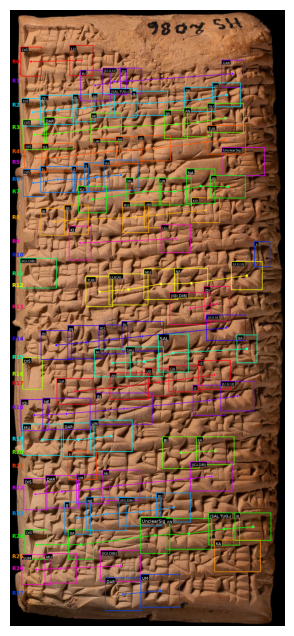

✓ Saved to: /home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree/alignment_results/debug_HS.2086_detection_rows.jpg


In [53]:
# ===== Step 6: Visualize matched rows - Detection with row numbers =====

import matplotlib.pyplot as plt

# Visualize detection rows with row numbers
det_row_vis = BboxVisualizer(color=(255, 0, 0))
det_row_vis.draw_rows(
    sub_tablet_detection.img.copy(),
    sub_tablet_detection.sign_boxes,
    show_labels=True,
    show_row_numbers=True,  # Show row numbers
    line_thickness=2,
    marker_size=5
)

print(f"Detection rows with row numbers (shown as 'R#' on left margin)")
print(f"R# = Detection row number (e.g., R0, R1, R2, ...)")
det_row_vis.display_result(vis_opt="draw")
det_row_vis.save(os.path.join(OUTPUT_DIR, f"debug_{sample}_detection_rows.jpg"))

Text rows with matched detection row numbers on left margin:
  'R#→D#' = Text row # matched to Detection row # (e.g., R0→D5 means text row 0 → detection row 5)
  'R#' only = Text row # not matched (e.g., R28 = unmatched, likely damage)


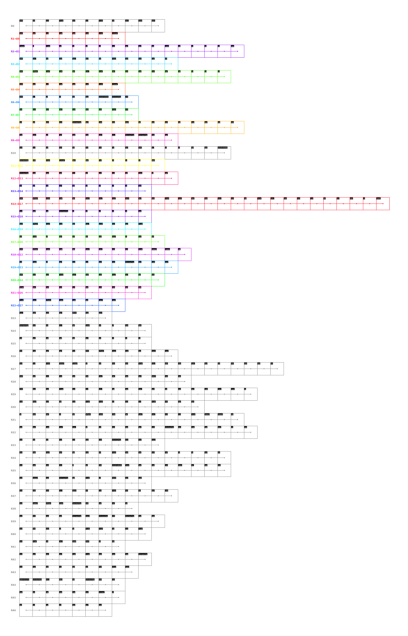

✓ Saved to: /home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree/alignment_results/debug_HS.2086_text_rows_mapped.jpg


In [54]:
# ===== Step 7: Visualize matched rows - Text with mapped detection row numbers =====

# Visualize text rows with mapping to detection rows
# Use row_mapping to show which detection row each text row corresponds to
text_row_vis = BboxVisualizer(color=(0, 0, 255))
text_row_vis.draw_rows(
    None,  # No background image for text (will create white canvas)
    sub_tablet_text.sign_boxes,
    show_labels=True,
    show_row_numbers=True,
    row_mapping=text_to_det,  # Map text row idx to detection row idx
    line_thickness=2,
    marker_size=5
)

print(f"Text rows with matched detection row numbers on left margin:")
print(f"  'R#→D#' = Text row # matched to Detection row # (e.g., R0→D5 means text row 0 → detection row 5)")
print(f"  'R#' only = Text row # not matched (e.g., R28 = unmatched, likely damage)")
text_row_vis.display_result(vis_opt="draw")
text_row_vis.save(os.path.join(OUTPUT_DIR, f"debug_{sample}_text_rows_mapped.jpg"))

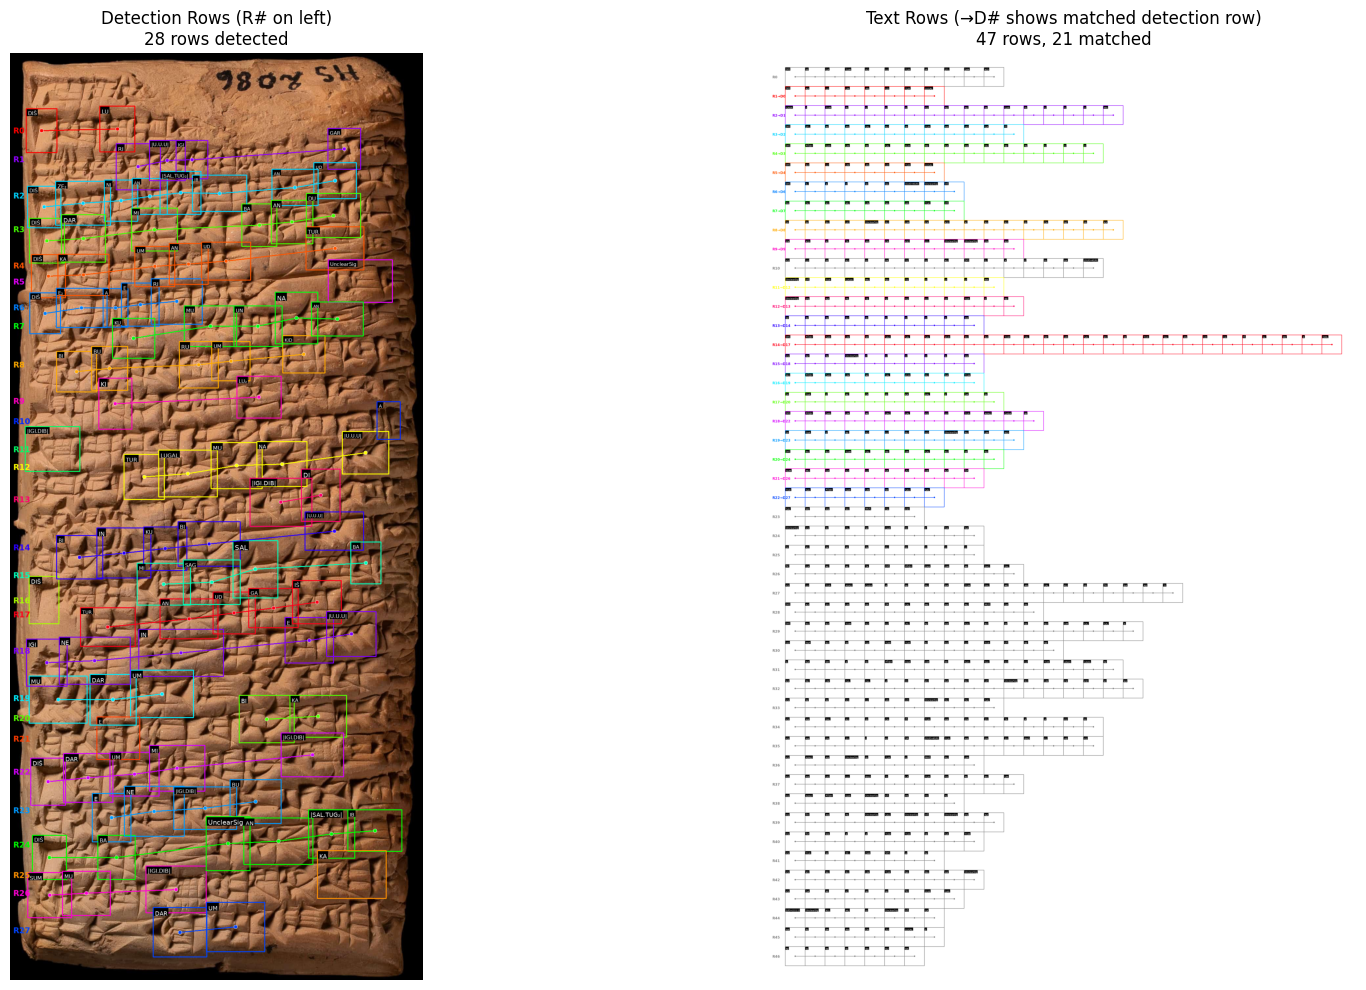


=== Matching Summary ===
Detection rows: 28
Text rows: 47
Matched rows: 21
Unmatched text rows: 26 (likely top/bottom damage)
Unmatched detection rows: 7 (likely noise)


In [84]:
# ===== Step 8: Side-by-side comparison of matched rows =====

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Detection with row numbers
axes[0].imshow(cv2.cvtColor(det_row_vis.result, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Detection Rows (R# on left)\n{len(det_row_sequences)} rows detected")
axes[0].axis('off')

# Text with mapped detection row numbers
axes[1].imshow(cv2.cvtColor(text_row_vis.result, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Text Rows (→D# shows matched detection row)\n{len(text_row_sequences)} rows, {len(matches)} matched")
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"\n=== Matching Summary ===")
print(f"Detection rows: {len(det_row_sequences)}")
print(f"Text rows: {len(text_row_sequences)}")
print(f"Matched rows: {len(matches)}")
print(f"Unmatched text rows: {len(text_row_sequences) - len(text_to_det)} (likely top/bottom damage)")
print(f"Unmatched detection rows: {len(det_row_sequences) - len(det_to_text)} (likely noise)")

In [85]:
# ===== Step 9: Within-row sign matching =====

from sign_alignment import match_signs_in_row_dp

# Perform sign-level matching for each matched row pair
row_sign_matches = {}  # {text_row_idx: [(text_sign_idx, det_sign_idx), ...]}

print(f"=== Within-Row Sign Matching ===")
print(f"Processing {len(matches)} matched row pairs...\n")

for text_row_idx, det_row_idx in matches:
    # Get sign sequences
    text_signs = text_row_sequences[text_row_idx]
    det_signs = det_row_sequences[det_row_idx]
    
    # Perform DP matching at sign level
    sign_matches, dp_matrix = match_signs_in_row_dp(
        detection_signs=det_signs,
        text_signs=text_signs,
        skip_text_penalty=0.5,
        skip_det_penalty=2.0,
        mismatch_cost=0.9
    )
    
    row_sign_matches[text_row_idx] = sign_matches
    
    print(f"Text row {text_row_idx} → Detection row {det_row_idx}:")
    print(f"  Text signs: {len(text_signs)}, Detection signs: {len(det_signs)}")
    print(f"  Matched signs: {len(sign_matches)}")
    print(f"  First 5 matches:")
    for i, (t_idx, d_idx) in enumerate(sign_matches[:5]):
        print(f"    {i+1}. Text[{t_idx}]={text_signs[t_idx]} ↔ Det[{d_idx}]={det_signs[d_idx]}")
    if len(sign_matches) > 5:
        print(f"    ... and {len(sign_matches)-5} more matches")
    print()

print(f"=== Sign Matching Summary ===")
total_text_signs = sum(len(text_row_sequences[t_idx]) for t_idx, _ in matches)
total_det_signs = sum(len(det_row_sequences[d_idx]) for _, d_idx in matches)
total_matched_signs = sum(len(sm) for sm in row_sign_matches.values())
print(f"Total text signs in matched rows: {total_text_signs}")
print(f"Total detection signs in matched rows: {total_det_signs}")
print(f"Total matched sign pairs: {total_matched_signs}")

=== Within-Row Sign Matching ===
Processing 21 matched row pairs...

Text row 1 → Detection row 0:
  Text signs: 8, Detection signs: 2
  Matched signs: 2
  First 5 matches:
    1. Text[0]=DIŠ ↔ Det[0]=DIŠ
    2. Text[2]=LU ↔ Det[1]=LU

Text row 2 → Detection row 1:
  Text signs: 17, Detection signs: 4
  Matched signs: 4
  First 5 matches:
    1. Text[11]=GAR ↔ Det[0]=GAR
    2. Text[12]=RI ↔ Det[1]=RI
    3. Text[13]=U ↔ Det[2]=|U.U.U|
    4. Text[14]=U ↔ Det[3]=IGI

Text row 3 → Detection row 2:
  Text signs: 12, Detection signs: 8
  Matched signs: 8
  First 5 matches:
    1. Text[1]=ZE₂ ↔ Det[0]=ZE₂
    2. Text[2]=NI ↔ Det[1]=IB
    3. Text[3]=AN ↔ Det[2]=DIŠ
    4. Text[4]=SAL ↔ Det[3]=NI
    5. Text[5]=KU ↔ Det[4]=|SAL.TUG₂|
    ... and 3 more matches

Text row 4 → Detection row 3:
  Text signs: 16, Detection signs: 6
  Matched signs: 6
  First 5 matches:
    1. Text[2]=DAR ↔ Det[0]=BA
    2. Text[3]=UM ↔ Det[1]=DIŠ
    3. Text[4]=MI ↔ Det[2]=MI
    4. Text[5]=SAL ↔ Det[3]=AN
    5

In [86]:
# ===== Step 10: Align text rows to detection rows based on sign matches =====

from sign_alignment import align_text_to_detection_rows

# Get all sign boxes grouped by row from both subtablets (as dictionaries)
det_rows = sub_tablet_detection.get_rows_dict()
text_rows = sub_tablet_text.get_rows_dict()

print(f"=== Row Alignment ===")
print(f"Aligning matched text rows to detection rows using baseline with slope...\n")

# Align all matched text rows to detection rows
aligned_text_boxes = align_text_to_detection_rows(
    det_rows=det_rows,
    text_rows=text_rows,
    text_to_det=text_to_det,
    row_sign_matches=row_sign_matches,
    avg_width=avg_width,
    avg_height=avg_height,
    min_width_ratio=2/3,
    max_width_ratio=4/3
)

print(f"\n=== Alignment Summary ===")
print(f"Total aligned sign boxes: {len(aligned_text_boxes)}")
print(f"Matched text rows aligned: {len(row_sign_matches)}")
print(f"(Only matched rows are processed; unmatched text rows are excluded)")


=== Row Alignment ===
Aligning matched text rows to detection rows using baseline with slope...


=== Alignment Summary ===
Total aligned sign boxes: 254
Matched text rows aligned: 21
(Only matched rows are processed; unmatched text rows are excluded)


In [87]:
# ===== Step 11: Create optimized (aligned) SubTablet =====

from sign_alignment import SubTablet

# Create new SubTablet with aligned sign boxes
sub_tablet_optim = SubTablet(
    sign_boxes=aligned_text_boxes,
    img=sub_tablet_detection.img,  # Use same image as detection
    name="optim",
    avg_width=avg_width,
    avg_height=avg_height
)

print(f"optimized subtablet created, info: {sub_tablet_optim.info}")

# Count signs per row in optim subtablet
from collections import Counter
optim_row_counts = Counter([sb.row_idx for sb in sub_tablet_optim.sign_boxes])
print(f"\n  Signs per row in optim subtablet:")
for row_idx in sorted(optim_row_counts.keys()):
    if row_idx >= 0:
        print(f"    Row {row_idx}: {optim_row_counts[row_idx]} signs")

print(f"\n  First 5 signs in optim subtablet:")
for i, sb in enumerate(sub_tablet_optim.sign_boxes[:5]):
    print(f"    {i+1}. {sb.sign_name} (row={sb.row_idx}): center=({sb.cx:.1f}, {sb.cy:.1f}), size=({sb.width:.1f}, {sb.height:.1f})")

optimized subtablet created, info: SubTablet 'optim':
  254 signs, 21 rows, 
  image shape: (2835, 1262, 3), heatmap shape: None
  avg_width: 138.99, avg_height: 133.66

  Signs per row in optim subtablet:
    Row 1: 8 signs
    Row 2: 17 signs
    Row 3: 12 signs
    Row 4: 16 signs
    Row 5: 8 signs
    Row 6: 9 signs
    Row 7: 9 signs
    Row 8: 17 signs
    Row 9: 12 signs
    Row 11: 11 signs
    Row 12: 12 signs
    Row 13: 10 signs
    Row 14: 28 signs
    Row 15: 10 signs
    Row 16: 10 signs
    Row 17: 11 signs
    Row 18: 13 signs
    Row 19: 12 signs
    Row 20: 11 signs
    Row 21: 10 signs
    Row 22: 8 signs

  First 5 signs in optim subtablet:
    1. DIŠ (row=1): center=(96.6, 237.6), size=(94.3, 133.7)
    2. KA (row=1): center=(282.0, 233.6), size=(185.3, 133.7)
    3. LU (row=1): center=(328.1, 232.6), size=(107.8, 133.7)
    4. UM (row=1): center=(652.6, 225.7), size=(185.3, 133.7)
    5. AN (row=1): center=(837.9, 221.8), size=(185.3, 133.7)


In [ ]:
# ===== Step 12: Visualize optimized subtablet =====

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# 1. Detection subtablet
det_vis2 = BboxVisualizer(color=(255, 0, 0))  # Red
det_vis2.draw_boxes(sub_tablet_detection.img.copy(), sub_tablet_detection.to_detection_list())
axes[0].imshow(cv2.cvtColor(det_vis2.result, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Detection SubTablet\n({len(sub_tablet_detection)} signs)")
axes[0].axis('off')

# 2. Optimized subtablet (after baseline alignment)
optim_vis = BboxVisualizer(color=(0, 255, 255))  # Cyan
optim_vis.draw_boxes(sub_tablet_optim.img.copy(), sub_tablet_optim.to_detection_list())
optim_vis.save(os.path.join(OUTPUT_DIR, f"debug_{sample}_initial_optimizing_subtablet.jpg"))
axes[1].imshow(cv2.cvtColor(optim_vis.result, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Optimized SubTablet (After Baseline Alignment)\n({len(sub_tablet_optim)} signs)")
axes[1].axis('off')

# 3. Overlay: Detection (red) + Optimized (cyan)
overlay_vis = BboxVisualizer(color=(255, 0, 0))  # Red for detection
overlay_vis.draw_boxes(sub_tablet_detection.img.copy(), sub_tablet_detection.to_detection_list())
overlay_vis2 = BboxVisualizer(color=(0, 255, 255))  # Cyan for optimized
overlay_vis2.draw_boxes(overlay_vis.result, sub_tablet_optim.to_detection_list())
overlay_vis2.save(os.path.join(OUTPUT_DIR, f"debug_{sample}_overlay_initial_detection_optim.jpg"))
axes[2].imshow(cv2.cvtColor(overlay_vis2.result, cv2.COLOR_BGR2RGB))
axes[2].set_title(f"Overlay: Detection (Red) + Optimized (Cyan)\nAlignment Quality Check")
axes[2].axis('off')

plt.tight_layout()
plt.show()


In [89]:
rows  = sub_tablet_optim.get_row_sign_sequences()
for i, row in enumerate(rows):
    print(row)

['DIŠ', 'KA', 'LU', 'UM', 'AN', 'UD', 'TUR', 'LUGAL']
['GABA', 'I', 'TUM', 'RI', 'U', 'U', 'U', 'IGI', 'NE', 'NE', 'IN', 'GAR', 'RI', 'U', 'U', 'U', 'MA']
['DIŠ', 'ZE₂', 'NI', 'AN', 'SAL', 'KU', 'IB', 'TUR', 'AN', 'UD', 'GA', 'IŠ']
['DIŠ', 'AŠ@z', 'DAR', 'UM', 'MI', 'SAL', 'KUR', 'ME', 'BA', 'AN', 'DU', 'NE', 'IN', 'U', 'U', 'U']
['DIŠ', 'KA', 'LU', 'UM', 'AN', 'UD', 'TUR', 'LUGAL']
['DIŠ', 'E₂', 'A', 'E', 'RI', 'BA', '|GUD×KUR|', 'UnclearSign', 'UŠ']
['PA', 'DU', 'KU', 'MU', 'UN', 'NA', 'AN', 'TUK', 'UŠ']
['DI', 'BI', 'BU', 'UD', 'UnclearSign', 'RU', 'UM', 'EN', 'KID', 'KI', 'KA', 'KU', 'BI', 'DA', 'NE', 'IN', 'KA']
['EN', 'KID', 'KI', 'TA', 'AN', 'EN', 'KID', 'LU₂', 'UnclearSign', 'UnclearSign', 'EN', 'NA']
['UnclearSign', 'UŠ', 'TUR', 'LUGAL', 'MU', 'NA', 'TE', 'U', 'U', 'U', 'MA']
['UnclearSign', 'EN', 'NA', 'PA', 'TE', 'SI', 'IGI', 'LU', 'DI', 'TAR', 'E', 'NE']
['DI', 'BI', 'IN', 'KU', 'BI', 'U', 'U', 'U', 'A', 'AN']
['DIŠ', 'AŠ@z', 'DAR', 'UM', 'MI', 'SAG', 'SAL', 'SAL', 'KUR', '

In [ ]:
# ↑ 
# ==================
# ↓